In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
zip_file_path = "/content/FruitinAmazon.zip"
extract_path = "/content/"

# Unzip the file silently (-q) to the specified extraction path (-d)
!unzip -q "{zip_file_path}" -d "{extract_path}"

print(f"Successfully extracted '{zip_file_path}' to '{extract_path}'.")

Successfully extracted '/content/FruitinAmazon.zip' to '/content/'.


###Data Visualization

['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


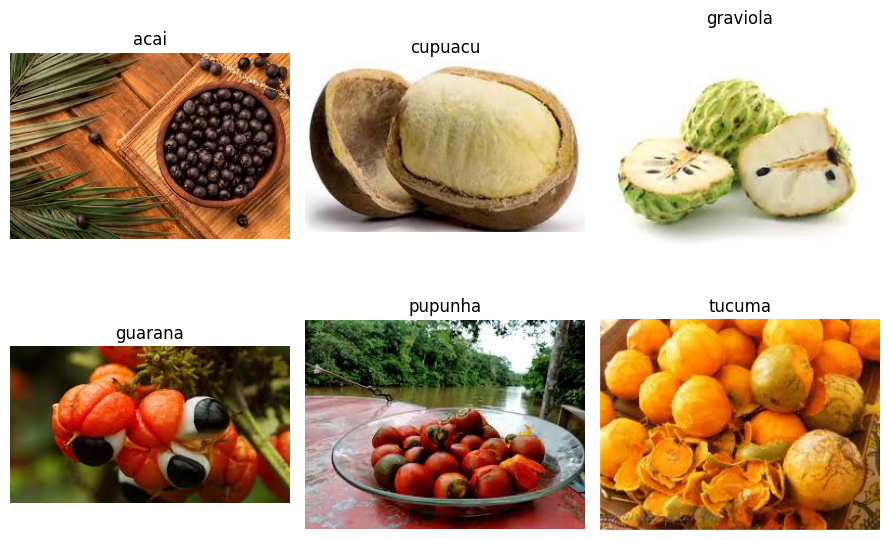

In [5]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

train_data_path = "/content/FruitinAmazon/train"
test_data_path = "/content/FruitinAmazon/test"

class_names = sorted([d for d in os.listdir(train_data_path) if os.path.isdir(os.path.join(train_data_path, d))])

print(class_names)

selected_images_paths = []
selected_class_names = []

for class_name in class_names:
    class_dir = "/content/FruitinAmazon/train/" + class_name

    image_files = [f for f in os.listdir(class_dir)]

    if image_files:
        random_image_name = random.choice(image_files)
        selected_images_paths.append(os.path.join(class_dir, random_image_name))
        selected_class_names.append(class_name)
    else:
        print(f"Warning: No image files found in class directory: {class_dir}")

num_images = len(selected_images_paths)
num_rows = 2
num_cols = (num_images + num_rows - 1) // num_rows
plt.figure(figsize=(num_cols * 3, num_rows * 3))

for i, img_path in enumerate(selected_images_paths):
    try:
        img = Image.open(img_path)
        plt.subplot(num_rows, num_cols, i + 1)
        plt.imshow(img)
        plt.title(selected_class_names[i])
        plt.axis("off")
    except Exception as e:
        print(f"Error loading or displaying image {img_path}: {e}")

plt.tight_layout()
plt.show()



 <h2><strong>What did you observe?</strong>

The dataset contains different classes of fruits, and each class has multiple images showing the fruit in various conditions like in different background, lighting, angle, and orientation. This helps to make the dataset more diverse and realistic and alos helps the model learn important features and improves its ability to generalize to unseen data.

###Corrupted Image Check

In [6]:
corrupted_images = []

for class_name in os.listdir(train_data_path):
    class_dir = os.path.join(train_data_path, class_name)

    if os.path.isdir(class_dir):
        for image_name in os.listdir(class_dir):
            image_path = os.path.join(class_dir, image_name)

            if os.path.isfile(image_path):
                try:
                    img = Image.open(image_path)
                    img.verify()
                except (IOError, SyntaxError) as e:
                    print(f"Removed corrupted image: {image_path}")
                    corrupted_images.append(image_path)
                    os.remove(image_path)
                except Exception as e:
                    print(f"An unexpected error occurred with {image_path}: {e}")
                    corrupted_images.append(image_path)

if not corrupted_images:
    print("No Corrupted Images Found.")

No Corrupted Images Found.


###Data Loading & Preprocessing

In [8]:
img_height = 128
img_width = 128
batch_size = 16

validation_split = 0.2

rescale = tf.keras.layers.Rescaling(1./255)

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
  train_data_path,
  labels="inferred",
  label_mode="int",
  image_size=(img_height, img_width),
  interpolation="nearest",
  batch_size=batch_size,
  shuffle=True,
  validation_split=validation_split,
  subset="training",
  seed=123
)

train_ds = train_ds.map(lambda x, y: (rescale(x), y))

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
  train_data_path,
  labels="inferred",
  label_mode="int",
  image_size=(img_height, img_width),
  interpolation="nearest",
  batch_size=batch_size,
  shuffle=False,
  validation_split=validation_split,
  subset="validation",
  seed=123
)

val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


In [9]:
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
  test_data_path,
  labels = 'inferred',
  label_mode = 'int',
  image_size = (img_height, img_width),
  interpolation = 'nearest',
  batch_size = batch_size,
  shuffle = False,
  seed = 123
)
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

Found 30 files belonging to 6 classes.


###CNN Architecture

In [21]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

num_classes = len(class_names)

model = keras.Sequential([
  layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(img_height, img_width, 3)),
  layers.MaxPooling2D((2, 2)),
  layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
  layers.MaxPooling2D((2, 2)),
  layers.Flatten(),
  layers.Dense(64, activation='relu'),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

checkpoint_filepath = 'best_model.h5'
model_checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_weights_only=False,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True
)

early_stopping_callback = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(train_ds,validation_data=val_ds,epochs=250, batch_size=16, callbacks=[model_checkpoint_callback, early_stopping_callback])

loss, accuracy = model.evaluate(test_ds)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

for images, labels in test_ds.take(1):
    predictions = model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)
    print("\nSample Predictions:")
    print("Predicted labels:", [class_names[p] for p in predicted_labels[:5]])
    print("Actual labels: ", [class_names[l] for l in labels.numpy()[:5]])

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step - accuracy: 0.1642 - loss: 1.9063

5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 398ms/step - accuracy: 0.1806 - loss: 1.9343 - val_accuracy: 0.0000e+00 - val_loss: 1.9284
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step - accuracy: 0.2170 - loss: 1.7090

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 308ms/step - accuracy: 0.2361 - loss: 1.6958 - val_accuracy: 0.2778 - val_loss: 1.6471
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step - accuracy: 0.3892 - loss: 1.5057

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 518ms/step - accuracy: 0.4306 - loss: 1.4865 - val_accuracy: 0.8333 - val_loss: 1.1695
Epoch 4/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 496ms/step - accuracy: 0.6250 - loss: 1.1404 - val_accuracy: 0.6667 - val_loss: 0.8613
Epoch 5/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - accuracy: 0.8542 - loss: 0.8519

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 300ms/step - accuracy: 0.8333 - loss: 0.8552 - val_accuracy: 0.8889 - val_loss: 0.6508
Epoch 6/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 296ms/step - accuracy: 0.9167 - loss: 0.4329 - val_accuracy: 0.2778 - val_loss: 1.4579
Epoch 7/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step - accuracy: 0.8816 - loss: 0.3254

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 329ms/step - accuracy: 0.8611 - loss: 0.3492 - val_accuracy: 0.9444 - val_loss: 0.3426
Epoch 8/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 306ms/step - accuracy: 0.9167 - loss: 0.2910 - val_accuracy: 0.8333 - val_loss: 0.4435
Epoch 9/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 284ms/step - accuracy: 0.9861 - loss: 0.1295 - val_accuracy: 0.8333 - val_loss: 0.6453
Epoch 10/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 279ms/step - accuracy: 0.9861 - loss: 0.0826 - val_accuracy: 0.8333 - val_loss: 0.2907
Epoch 11/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 355ms/step - accuracy: 1.0000 - loss: 0.0467 - val_accuracy: 0.9444 - val_loss: 0.2269
Epoch 12/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 513ms/step - accuracy: 1.0000 - loss: 0.0267 - val_accuracy: 0.7778 - val_loss: 0.4587
Epoch 13/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 390ms/step - accuracy: 1.0000 - loss: 0.0165 - val_accuracy: 0.7778 - val_loss: 0.6638
Epoch 14/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 289ms/step - accuracy: 1.0000 - loss: 0.0089 - val_accuracy: 0.8889 - val_loss

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step

Sample Predictions:
Predicted labels: ['guarana', 'cupuacu', 'acai', 'acai', 'acai']
Actual labels:  ['acai', 'acai', 'acai', 'acai', 'acai']


###Training and Validation Analysis

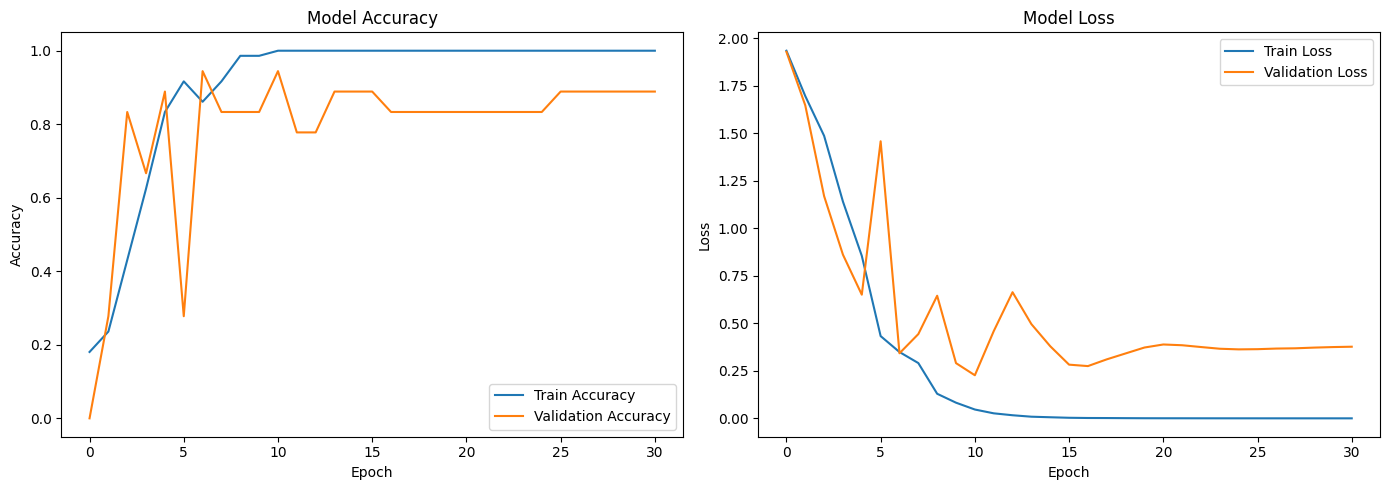

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
plt.tight_layout()
plt.show()

<h3><strong>Training and Validation Analysis</strong></h3>

<p>
The training accuracy increases to 100%, while the validation accuracy stabilizes around 80–90%. The training loss decreases to near zero, but the validation loss shows fluctuations. This indicates overfitting, where the model learns the training data very well but does not generalize effectively to unseen data.
</p>

In [23]:
loss, accuracy = model.evaluate(val_ds)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.9444 - loss: 0.2269 
Validation Loss: 0.2269
Validation Accuracy: 0.9444


In [24]:
model_save_path = 'fruit_classifier_model.h5'
model.save(model_save_path)
print(f"Model saved to {model_save_path}")

Model saved to fruit_classifier_model.h5


In [26]:
loaded_model = keras.models.load_model('fruit_classifier_model.h5')
print("Model loaded successfully!")

loaded_loss, loaded_accuracy = loaded_model.evaluate(val_ds)
print(f"\nLoaded Model Validation Loss: {loaded_loss:.4f}")
print(f"Loaded Model Validation Accuracy: {loaded_accuracy:.4f}")

Model loaded successfully!
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9444 - loss: 0.2269 

Loaded Model Validation Loss: 0.2269
Loaded Model Validation Accuracy: 0.9444


###Classification Report

In [27]:
from sklearn.metrics import classification_report

y_true = []
y_pred_probs = []

for images, labels in test_ds:
  preds = loaded_model.predict(images, verbose=0)
  y_pred_probs.extend(preds)
  y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.argmax(np.array(y_pred_probs), axis=1)
print('Predicted labels:', [class_names[i] for i in y_pred[:5]])
print('Actual labels :', [class_names[i] for i in y_true[:5]])

print(classification_report(y_true, y_pred, target_names=class_names))

Predicted labels: ['guarana', 'cupuacu', 'acai', 'acai', 'acai']
Actual labels : ['acai', 'acai', 'acai', 'acai', 'acai']
              precision    recall  f1-score   support

        acai       1.00      0.60      0.75         5
     cupuacu       0.57      0.80      0.67         5
    graviola       0.75      0.60      0.67         5
     guarana       0.71      1.00      0.83         5
     pupunha       1.00      0.20      0.33         5
      tucuma       0.62      1.00      0.77         5

    accuracy                           0.70        30
   macro avg       0.78      0.70      0.67        30
weighted avg       0.78      0.70      0.67        30



###Confusion Matrix

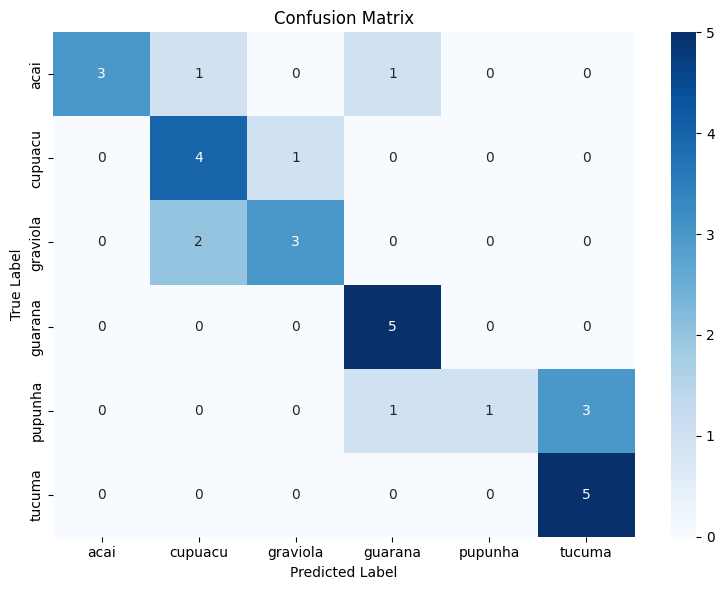

In [29]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=class_names, yticklabels=class_names)

plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()